<a href="https://colab.research.google.com/github/yuvanesh-art/BigBasket-Social-Media-Engagement-Dashboard-Project-Goal/blob/main/engagement_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Created Successfully!
        Date   Platform  Likes  Comments  Shares  Impressions  Reach  \
0 2026-01-01  Instagram   2865       538     209        49346  13112   
1 2026-01-02    Twitter   3602       902     139        37888  38225   
2 2026-01-03    Twitter   3245       345     356        34631  35212   
3 2026-01-04    YouTube   1550       381     243        21052  13618   
4 2026-01-05    Twitter   3435       694     249        23671  22557   

  Content_Type  
0        Video  
1        Video  
2         Reel  
3        Video  
4         Reel  

Checking Missing Values:
Date            0
Platform        0
Likes           0
Comments        0
Shares          0
Impressions     0
Reach           0
Content_Type    0
dtype: int64

Data Cleaning Completed!

Engagement Rate Added!

========== BASIC ANALYSIS ==========

Total Likes:
83714

Total Comments:
15075

Total Shares:
8010

Platform-wise Engagement:
           Likes  Comments  Shares
Platform                          
Inst

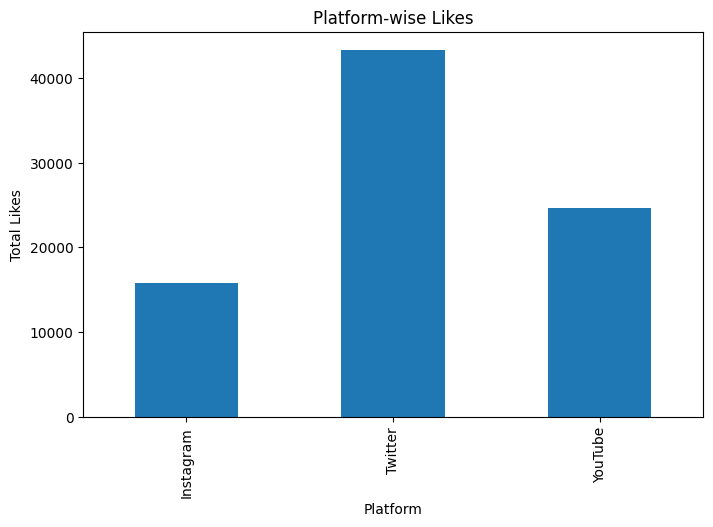

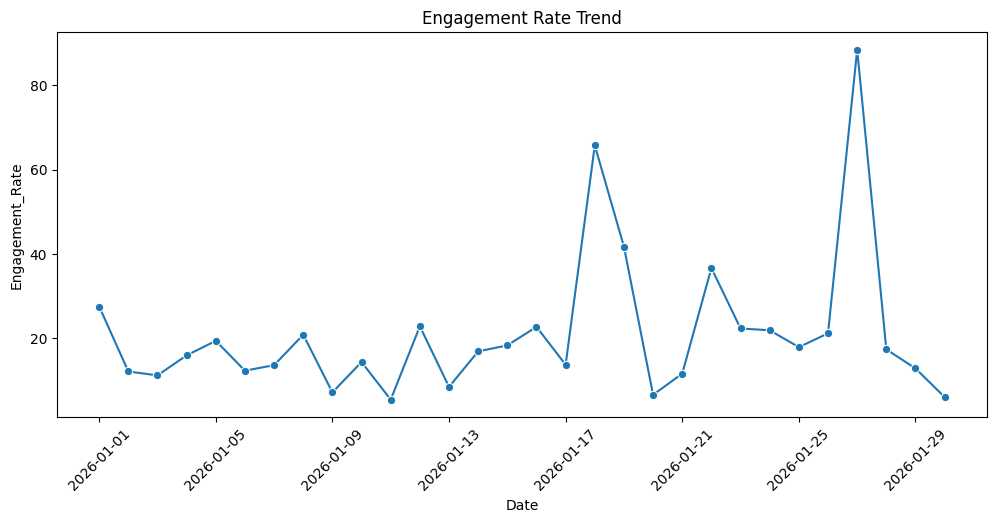

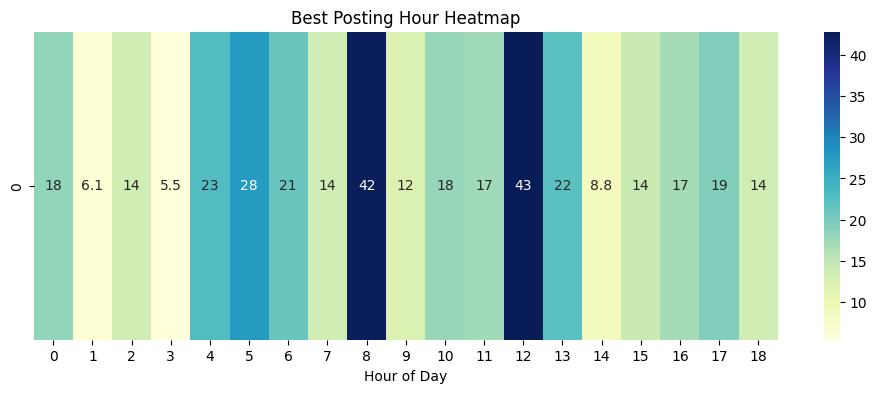


Processed Dataset Saved!

========== DASHBOARD INSIGHTS ==========

Top Performing Platform: Twitter
Best Content Type: Story
Best Posting Hour: 17:00 hrs
Average Engagement Rate: 21.12%


Charts Saved Successfully!

BigBasket Social Media Engagement Dashboard Completed!


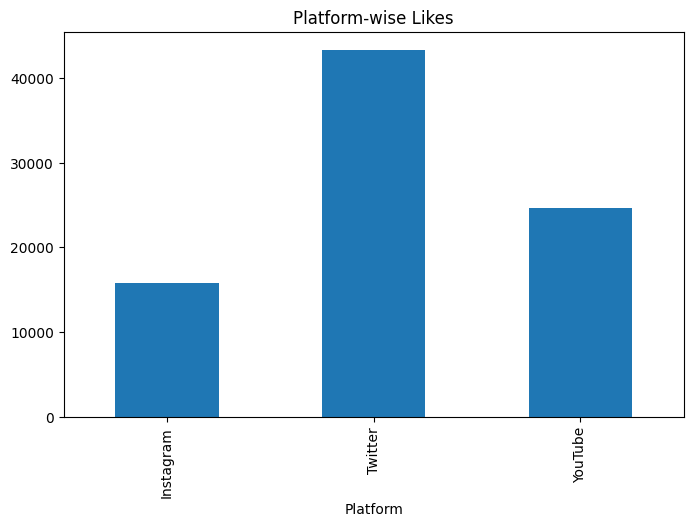

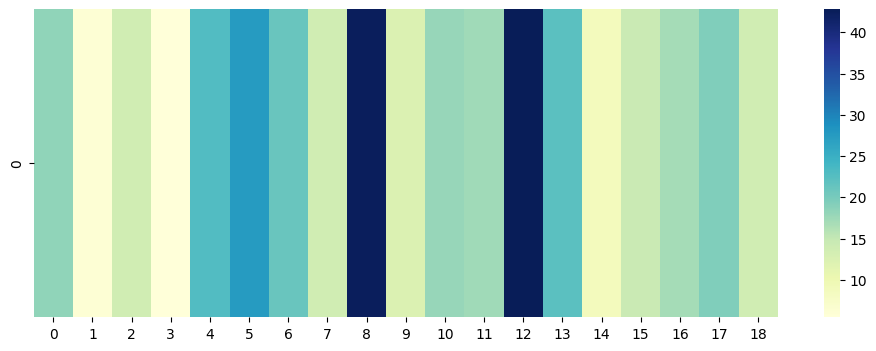

In [ ]:
# =========================================================
# BigBasket Social Media Engagement Dashboard
# Complete Google Colab Python Code
# =========================================================

# -----------------------------
# STEP 1 — Install Libraries
# -----------------------------

!pip install pandas numpy matplotlib seaborn plotly --quiet

# -----------------------------
# STEP 2 — Import Libraries
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# -----------------------------
# STEP 3 — Create Sample Dataset
# -----------------------------

data = {
    'Date': pd.date_range(start='2026-01-01', periods=30),

    'Platform': np.random.choice(
        ['Instagram', 'YouTube', 'Twitter'],
        30
    ),

    'Likes': np.random.randint(500, 5000, 30),

    'Comments': np.random.randint(50, 1000, 30),

    'Shares': np.random.randint(20, 500, 30),

    'Impressions': np.random.randint(5000, 50000, 30),

    'Reach': np.random.randint(3000, 40000, 30),

    'Content_Type': np.random.choice(
        ['Reel', 'Post', 'Video', 'Story'],
        30
    )
}

# Create DataFrame
df = pd.DataFrame(data)

# Save Dataset
df.to_csv('social_media_data.csv', index=False)

print("Dataset Created Successfully!")
print(df.head())

# -----------------------------
# STEP 4 — Data Cleaning
# -----------------------------

print("\nChecking Missing Values:")
print(df.isnull().sum())

# Remove Missing Values
df.dropna(inplace=True)

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

print("\nData Cleaning Completed!")

# -----------------------------
# STEP 5 — Create Engagement Rate
# -----------------------------

df['Engagement_Rate'] = (
    (
        df['Likes'] +
        df['Comments'] +
        df['Shares']
    ) / df['Reach']
) * 100

print("\nEngagement Rate Added!")

# -----------------------------
# STEP 6 — Basic Analysis
# -----------------------------

print("\n========== BASIC ANALYSIS ==========")

print("\nTotal Likes:")
print(df['Likes'].sum())

print("\nTotal Comments:")
print(df['Comments'].sum())

print("\nTotal Shares:")
print(df['Shares'].sum())

# Platform-wise Analysis
platform_analysis = df.groupby('Platform')[
    ['Likes', 'Comments', 'Shares']
].sum()

print("\nPlatform-wise Engagement:")
print(platform_analysis)

# -----------------------------
# STEP 7 — Content Type Analysis
# -----------------------------

content_analysis = df.groupby(
    'Content_Type'
)['Engagement_Rate'].mean()

print("\nContent Type Performance:")
print(content_analysis)

# -----------------------------
# STEP 8 — Best Posting Time
# -----------------------------

# Generate Random Posting Hours
df['Posting_Hour'] = np.random.randint(
    0,
    24,
    len(df)
)

best_time = df.groupby(
    'Posting_Hour'
)['Engagement_Rate'].mean()

print("\nBest Posting Hours:")
print(
    best_time.sort_values(
        ascending=False
    ).head()
)

# -----------------------------
# STEP 9 — Visualization
# -----------------------------

# ====================================
# BAR CHART — Platform Likes
# ====================================

plt.figure(figsize=(8,5))

platform_analysis['Likes'].plot(
    kind='bar'
)

plt.title('Platform-wise Likes')
plt.xlabel('Platform')
plt.ylabel('Total Likes')

plt.show()

# ====================================
# LINE CHART — Engagement Trend
# ====================================

plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x='Date',
    y='Engagement_Rate',
    marker='o'
)

plt.title('Engagement Rate Trend')
plt.xticks(rotation=45)

plt.show()

# ====================================
# PIE CHART — Content Performance
# ====================================

content_data = df.groupby(
    'Content_Type'
)['Engagement_Rate'].mean().reset_index()

fig = px.pie(
    content_data,
    names='Content_Type',
    values='Engagement_Rate',
    title='Content Type Performance'
)

fig.show()

# ====================================
# HEATMAP — Best Posting Hour
# ====================================

plt.figure(figsize=(12,4))

sns.heatmap(
    best_time.values.reshape(1, -1),
    cmap='YlGnBu',
    annot=True
)

plt.title('Best Posting Hour Heatmap')
plt.xlabel('Hour of Day')

plt.show()

# -----------------------------
# STEP 10 — Save Processed Data
# -----------------------------

df.to_csv(
    'processed_social_data.csv',
    index=False
)

print("\nProcessed Dataset Saved!")

# -----------------------------
# STEP 11 — Dashboard Insights
# -----------------------------

print("\n========== DASHBOARD INSIGHTS ==========")

top_platform = platform_analysis[
    'Likes'
].idxmax()

print(f"\nTop Performing Platform: {top_platform}")

best_content = content_analysis.idxmax()

print(f"Best Content Type: {best_content}")

best_posting_hour = best_time.idxmax()

print(f"Best Posting Hour: {best_posting_hour}:00 hrs")

average_engagement = round(
    df['Engagement_Rate'].mean(),
    2
)

print(f"Average Engagement Rate: {average_engagement}%")

print("\n========================================")

# -----------------------------
# STEP 12 — Export Charts
# -----------------------------

# Save Bar Chart
plt.figure(figsize=(8,5))

platform_analysis['Likes'].plot(kind='bar')

plt.title('Platform-wise Likes')

plt.savefig('engagement_chart.png')

# Save Heatmap
plt.figure(figsize=(12,4))

sns.heatmap(
    best_time.values.reshape(1, -1),
    cmap='YlGnBu'
)

plt.savefig('posting_time_heatmap.png')

print("\nCharts Saved Successfully!")

# =========================================================
# END OF PROJECT
# =========================================================

print("\nBigBasket Social Media Engagement Dashboard Completed!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv('social_media_data.csv')

In [ ]:
df.head()

,Date,Platform,Likes,Comments,Shares,Impressions,Reach,Content_Type
0,2026-01-01,Instagram,2865,538,209,49346,13112,Video
1,2026-01-02,Twitter,3602,902,139,37888,38225,Video
2,2026-01-03,Twitter,3245,345,356,34631,35212,Reel
3,2026-01-04,YouTube,1550,381,243,21052,13618,Video
4,2026-01-05,Twitter,3435,694,249,23671,22557,Reel


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          30 non-null     object
 1   Platform      30 non-null     object
 2   Likes         30 non-null     int64 
 3   Comments      30 non-null     int64 
 4   Shares        30 non-null     int64 
 5   Impressions   30 non-null     int64 
 6   Reach         30 non-null     int64 
 7   Content_Type  30 non-null     object
dtypes: int64(5), object(3)
memory usage: 2.0+ KB


In [ ]:
df.isnull().sum()
df['Engagement_Rate'] = (
    (
        df['Likes'] +
        df['Comments'] +
        df['Shares']
    ) / df['Reach']
) * 100

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.head()

,Date,Platform,Likes,Comments,Shares,Impressions,Reach,Content_Type,Engagement_Rate
0,2026-01-01,Instagram,2865,538,209,49346,13112,Video,27.547285
1,2026-01-02,Twitter,3602,902,139,37888,38225,Video,12.146501
2,2026-01-03,Twitter,3245,345,356,34631,35212,Reel,11.206407
3,2026-01-04,YouTube,1550,381,243,21052,13618,Video,15.964165
4,2026-01-05,Twitter,3435,694,249,23671,22557,Reel,19.408609


In [ ]:
df.to_csv(
    'processed_social_data.csv',
    index=False
)

In [ ]:
print("Total Likes:", df['Likes'].sum())
print("Total Comments:", df['Comments'].sum())
print("Total Shares:", df['Shares'].sum())

Total Likes: 83714
Total Comments: 15075
Total Shares: 8010


In [ ]:
platform_analysis = df.groupby('Platform')[
    ['Likes', 'Comments', 'Shares']
].sum()

print(platform_analysis)

           Likes  Comments  Shares
Platform                          
Instagram  15811      2212    1544
Twitter    43268      9010    3715
YouTube    24635      3853    2751


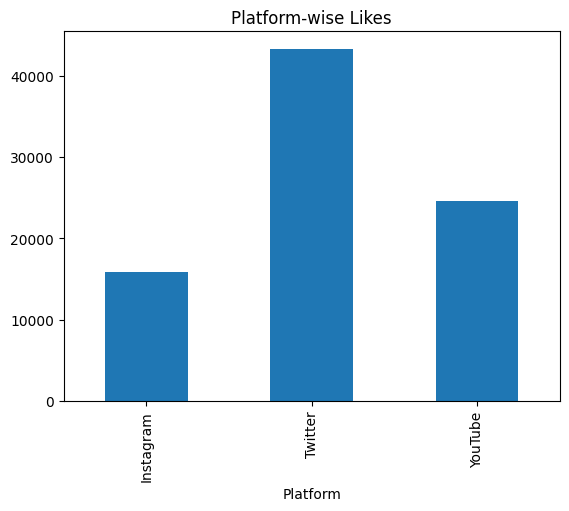

In [ ]:
platform_analysis['Likes'].plot(kind='bar')

plt.title('Platform-wise Likes')

plt.show()